# Wine Quality Classification
## POSTECH – DTAT – Tech Challenge Fase 2

**Dataset:** `WineQT.csv` — 1.143 amostras de vinho tinto  
**Objetivo:** Classificar vinhos como *Alta Qualidade* (nota ≥ 7) ou *Baixa/Média Qualidade* (nota < 7).

## 0. Setup e Imports

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)
from sklearn.inspection import permutation_importance
from preprocess import full_preprocess, load_wine_data, create_binary_target, engineer_features

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

A## 1. Compreensão do Problema

A avaliação sensorial de vinhos é subjetiva e custosa. O desafio é construir um modelo preditivo que, a partir de atributos físico-químicos mensuráveis durante a produção, classifique automaticamente um vinho como Alta Qualidade (nota ≥ 7) ou Baixa/Média Qualidade (nota < 7).

Dataset: WineQT.csv — vinho tinto, 1.143 amostras, 11 variáveis preditoras + coluna `Id` (descartada).

**Variável alvo:** `high_quality` (binária)
- `1` → nota ≥ 7 (Alta qualidade)
- `0` → nota < 7 (Baixa/Média qualidade)

## 2. Carregamento e Entendimento dos Dados

In [2]:
df_raw = load_wine_data('../data', 'WineQT.csv')
df_raw.head()

[load] Coluna 'Id' removida.
[load] ../data\WineQT.csv: 1143 linhas, 12 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [4]:
df_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.000000,8.311111,1.747595,4.600000,7.100000,7.900000,9.100000,15.900000
volatile acidity,1143.000000,0.531339,0.179633,0.120000,0.392500,0.520000,0.640000,1.580000
citric acid,1143.000000,0.268364,0.196686,0.000000,0.090000,0.250000,0.420000,1.000000
residual sugar,1143.000000,2.532152,1.355917,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1143.000000,0.086933,0.047267,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1143.000000,15.615486,10.250486,1.000000,7.000000,13.000000,21.000000,68.000000
total sulfur dioxide,1143.000000,45.914698,32.782130,6.000000,21.000000,37.000000,61.000000,289.000000
density,1143.000000,0.996730,0.001925,0.990070,0.995570,0.996680,0.997845,1.003690
pH,1143.000000,3.311015,0.156664,2.740000,3.205000,3.310000,3.400000,4.010000
sulphates,1143.000000,0.657708,0.170399,0.330000,0.550000,0.620000,0.730000,2.000000


### 2.1 Verificação de valores faltantes

In [5]:
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Nenhum valor faltante.')

Nenhum valor faltante.


### 2.2 Transformação da variável alvo

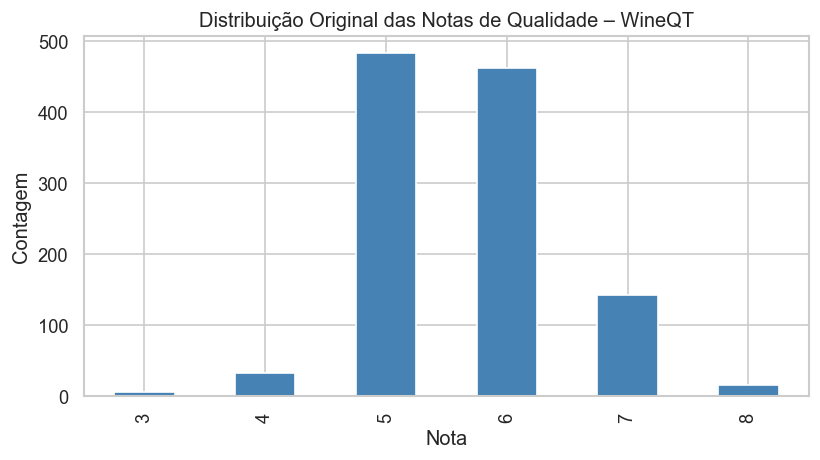

[target] Alta qualidade (nota >= 7): 159 amostras (13.9%)
[target] Baixa/Média  (nota <  7): 984 amostras (86.1%)


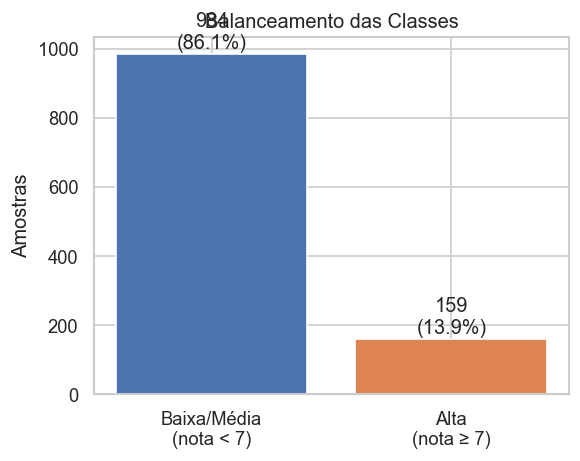

In [6]:
# Distribuição original das notas
fig, ax = plt.subplots(figsize=(7, 4))
df_raw['quality'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Distribuição Original das Notas de Qualidade – WineQT')
ax.set_xlabel('Nota'); ax.set_ylabel('Contagem')
plt.tight_layout()
plt.savefig('../results/distribuicao_notas_original.png')
plt.show()

# Cria variável binária
df = create_binary_target(df_raw.copy())

# Balanceamento
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['high_quality'].value_counts()
bars = ax.bar(['Baixa/Média\n(nota < 7)', 'Alta\n(nota ≥ 7)'],
              [counts[0], counts[1]], color=['#4C72B0','#DD8452'], edgecolor='white')
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom')
ax.set_title('Balanceamento das Classes')
ax.set_ylabel('Amostras')
plt.tight_layout()
plt.savefig('../results/balanceamento_classes.png')
plt.show()

## 3. Análise Exploratória de Dados (EDA)

> **Nota sobre desbalanceamento:** O WineQT tem ~86% de amostras Baixa/Média e apenas ~14% Alta qualidade. Isso impacta diretamente a escolha de métricas (AUC e F1 são mais adequadas que acurácia pura) e a configuração dos modelos (`class_weight='balanced'`).

### 3.1 Distribuição das variáveis por classe

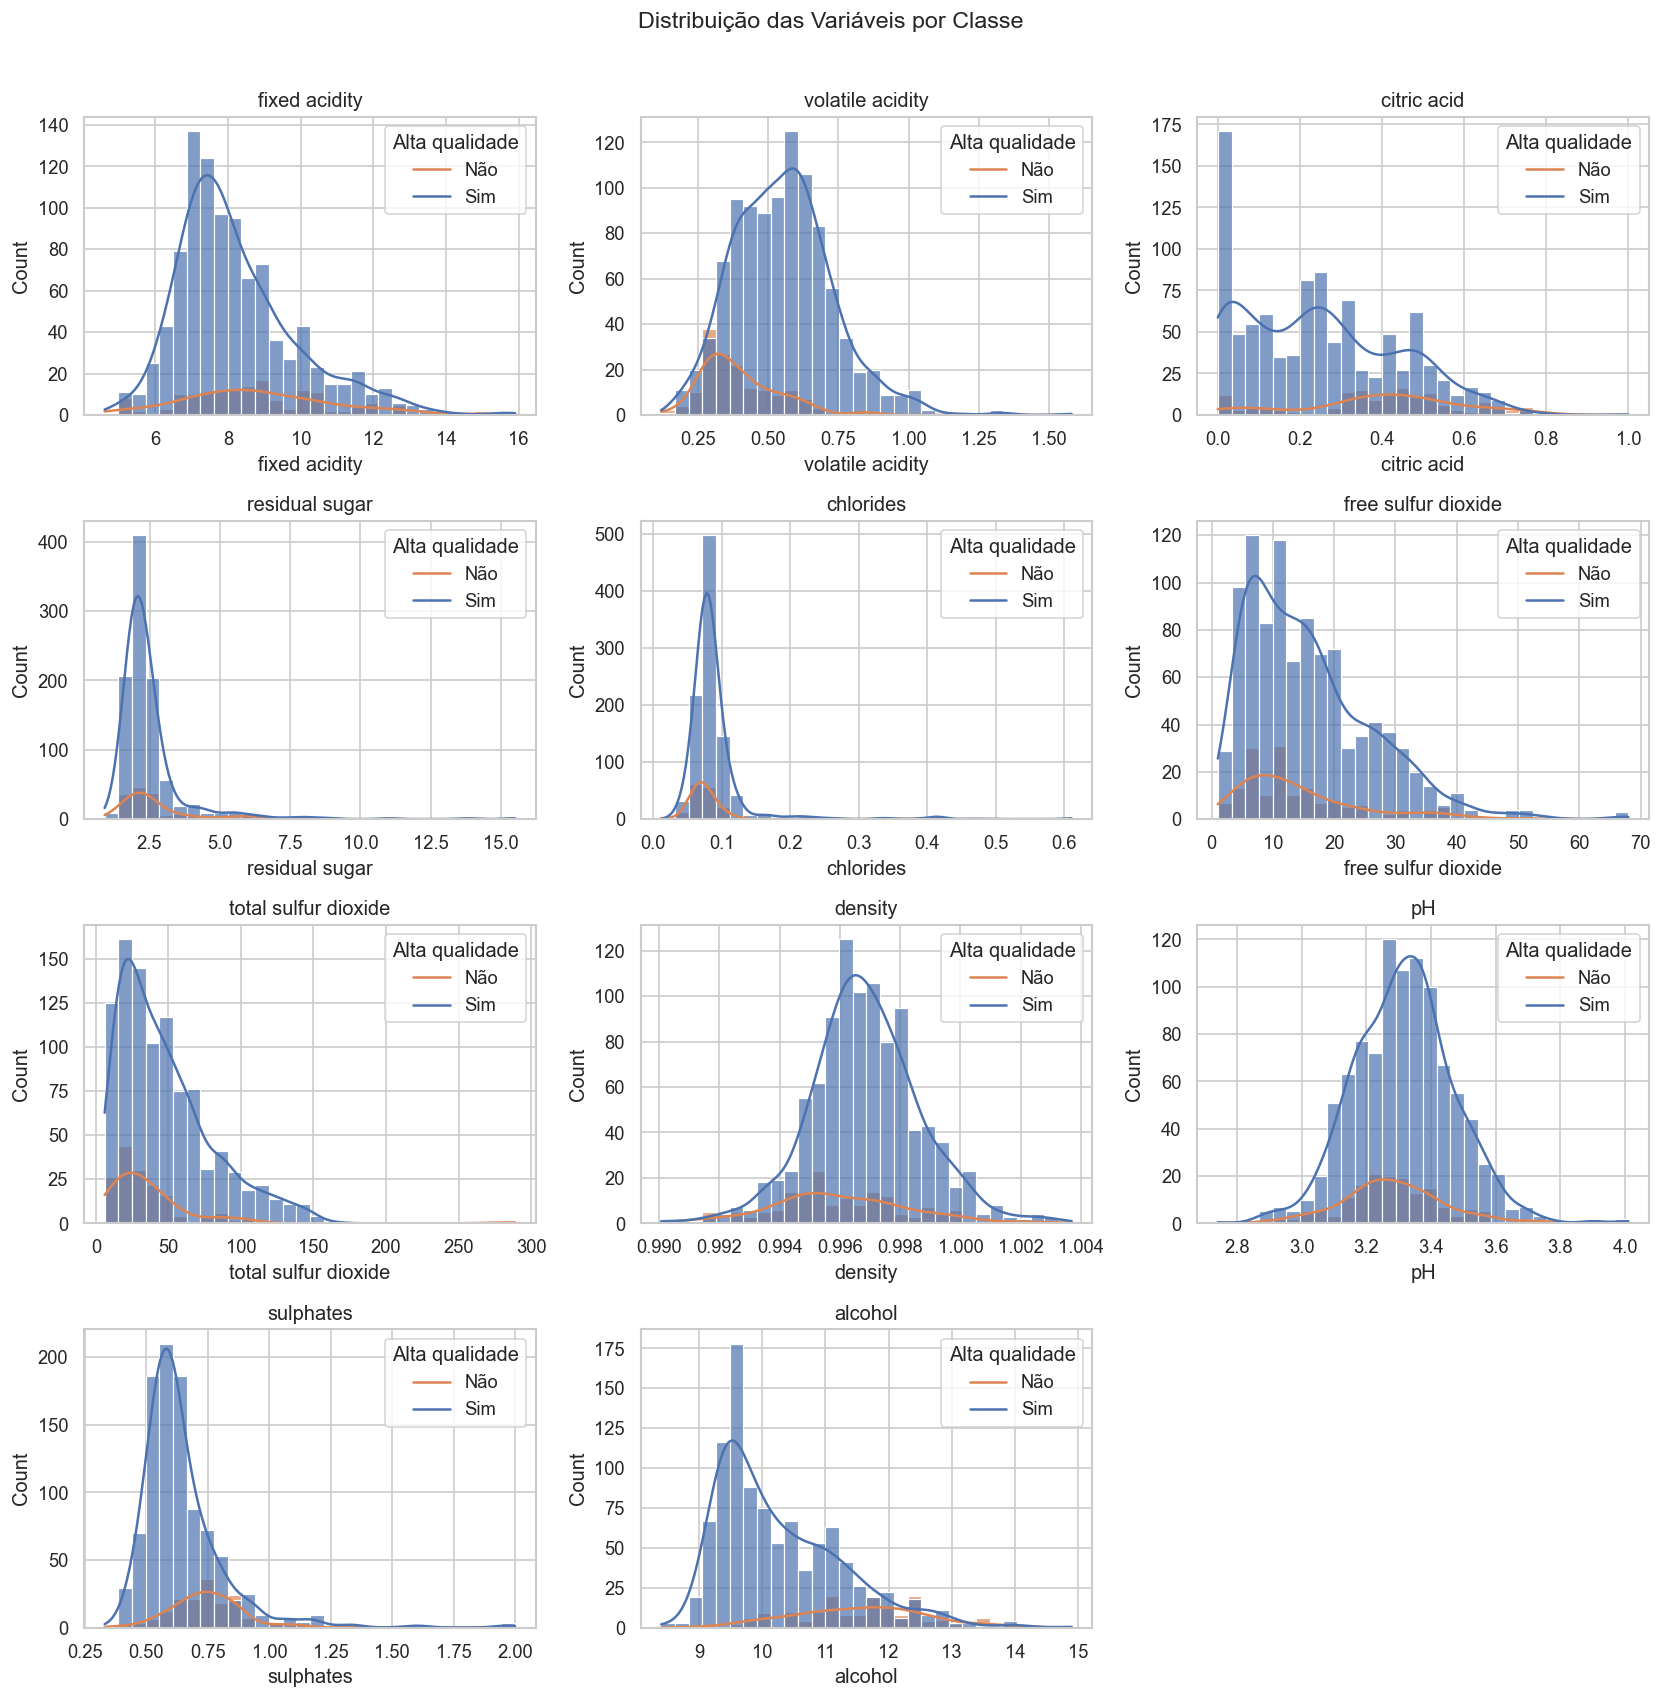

In [7]:
feature_cols = ['fixed acidity','volatile acidity','citric acid','residual sugar',
                'chlorides','free sulfur dioxide','total sulfur dioxide',
                'density','pH','sulphates','alcohol']

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, hue='high_quality', bins=30, ax=axes[i],
                 palette={0:'#4C72B0', 1:'#DD8452'}, alpha=0.7, kde=True)
    axes[i].set_title(col)
    axes[i].legend(title='Alta qualidade', labels=['Não','Sim'])
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuição das Variáveis por Classe', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/distribuicao_variaveis.png', bbox_inches='tight')
plt.show()

### 3.2 Correlações

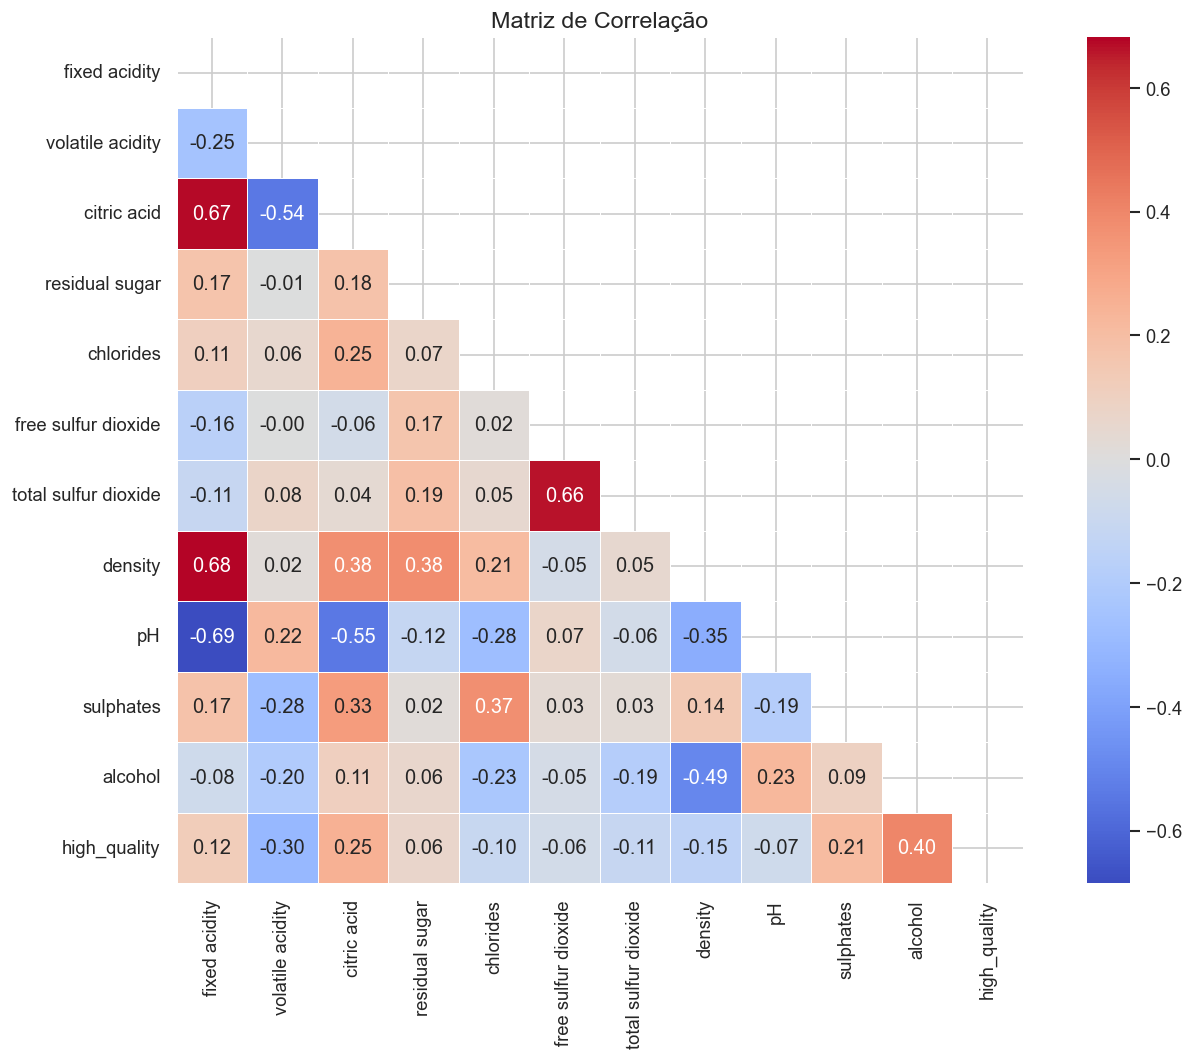

Correlação com high_quality:
alcohol                 0.403676
citric acid             0.251146
sulphates               0.208020
fixed acidity           0.123212
residual sugar          0.064145
free sulfur dioxide    -0.055977
pH                     -0.073318
chlorides              -0.103985
total sulfur dioxide   -0.113373
density                -0.148670
volatile acidity       -0.304523


In [8]:
corr = df[feature_cols + ['high_quality']].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.savefig('../results/correlacao.png')
plt.show()

print('Correlação com high_quality:')
print(corr['high_quality'].drop('high_quality').sort_values(ascending=False).to_string())

### 3.3 Boxplots – outliers e separação entre classes

ValueError: The palette dictionary is missing keys: {'1', '0'}

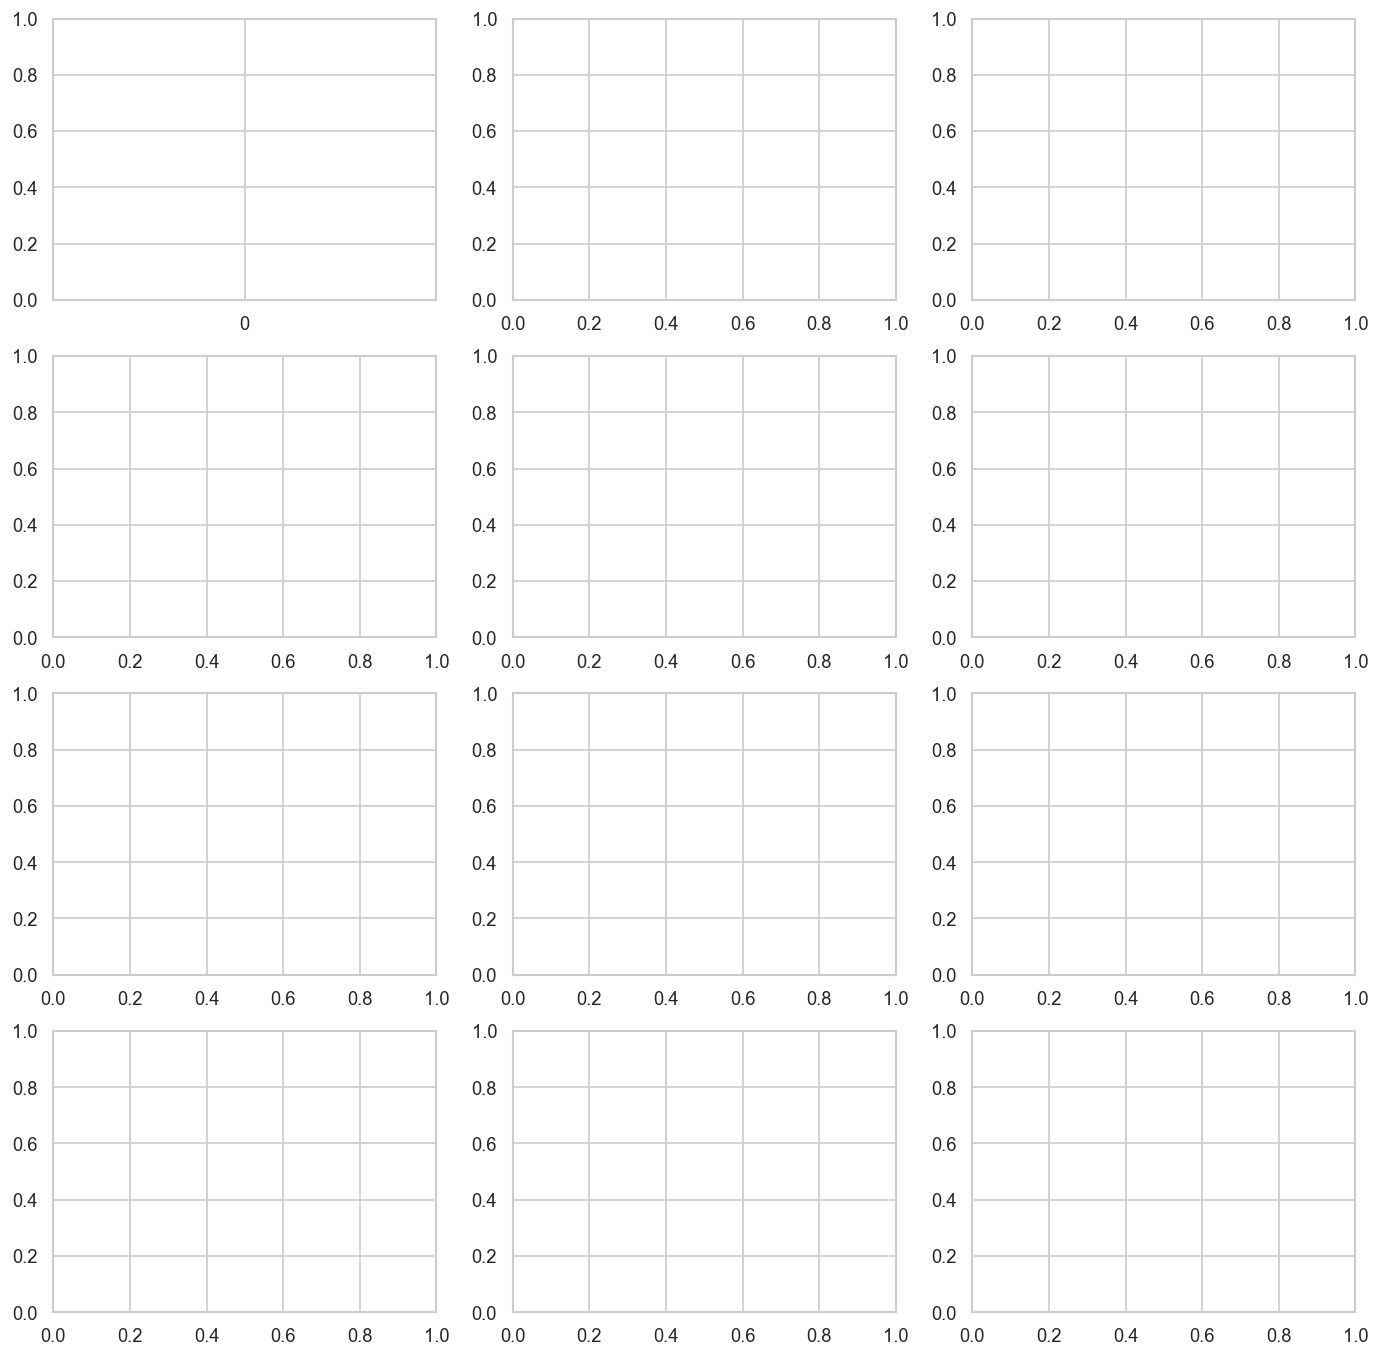

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x='high_quality', y=col, ax=axes[i],
                palette={0:'#4C72B0', 1:'#DD8452'})
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Baixa/Média','Alta'])
    axes[i].set_xlabel('Qualidade')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots por Classe de Qualidade', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/boxplots.png', bbox_inches='tight')
plt.show()

## 4. Pré-processamento e Feature Engineering

In [ ]:
import os
os.makedirs('../results', exist_ok=True)

X, y = full_preprocess('../data', 'WineQT.csv')
print('Features finais:', list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Alta qualidade – treino: {y_train.mean()*100:.1f}% | teste: {y_test.mean()*100:.1f}%')

## 5. Desenvolvimento dos Modelos

Três modelos treinados em Pipeline com `StandardScaler` e `class_weight='balanced'` para compensar o desbalanceamento:

| Modelo | Motivação |
|---|---|
| **Logistic Regression** | Baseline linear; coeficientes interpretáveis |
| **Random Forest** | Robusto a outliers; feature importance nativa |
| **Gradient Boosting** | Alta performance; captura não-linearidades |

In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                    random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                        random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                            max_depth=4, subsample=0.8,
                                            random_state=RANDOM_STATE))
    ])
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('=== Cross-Validation (5-Fold, AUC) ===')
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

## 6. Avaliação dos Modelos

In [ ]:
results = []
trained = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    trained[name] = pipeline
    y_pred      = pipeline.predict(X_test)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_prob),
    })

results_df = pd.DataFrame(results).set_index('Modelo')
results_df.style.background_gradient(cmap='Greens').format('{:.4f}')

In [ ]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipeline in trained.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('Curvas ROC – Comparativo entre Modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/roc_curves.png')
plt.show()

In [ ]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipeline) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, pipeline.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Baixa/Média','Alta']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)
plt.suptitle('Matrizes de Confusão', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', bbox_inches='tight')
plt.show()

In [ ]:
# Comparativo de métricas
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x, width = np.arange(len(metrics)), 0.25
colors   = ['#4C72B0','#DD8452','#55A868']
fig, ax  = plt.subplots(figsize=(11, 5))
for i, (name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width, label=name, color=colors[i])
ax.set_xticks(x + width); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05); ax.set_title('Comparativo de Métricas por Modelo')
ax.legend(); ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('../results/comparativo_metricas.png')
plt.show()
results_df

## 7. Interpretação dos Resultados

In [ ]:
# Feature Importance – Random Forest
rf_clf = trained['Random Forest'].named_steps['clf']
imp    = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importância das Features – Random Forest (MDI)')
ax.set_xlabel('Importância média')
plt.tight_layout()
plt.savefig('../results/feature_importance_rf.png')
plt.show()

In [ ]:
best_name     = results_df['ROC-AUC'].idxmax()
best_pipeline = trained[best_name]
print(f'Melhor modelo por AUC: {best_name}')
print(classification_report(y_test, best_pipeline.predict(X_test),
                             target_names=['Baixa/Média','Alta']))

perm = permutation_importance(best_pipeline, X_test, y_test,
                               n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc')
perm_df = pd.DataFrame({'Feature': X.columns,
                         'mean': perm.importances_mean,
                         'std':  perm.importances_std}).sort_values('mean')
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(perm_df['Feature'], perm_df['mean'], xerr=perm_df['std'],
        color='coral', edgecolor='white')
ax.set_title(f'Permutation Importance – {best_name}')
ax.set_xlabel('Redução média no AUC')
plt.tight_layout()
plt.savefig('../results/permutation_importance.png')
plt.show()

## 8. Conclusões

### Principais achados da EDA
- **Desbalanceamento acentuado:** ~86% Baixa/Média vs ~14% Alta qualidade — justifica `class_weight='balanced'` e uso de AUC/F1 como métricas principais.
- **`alcohol`** tem a correlação positiva mais forte com alta qualidade.
- **`volatile acidity`** correlaciona negativamente (deterioração bacteriana).
- **`sulphates`** têm correlação positiva moderada.
- **`citric acid`** e **`fixed acidity`** têm correlação positiva fraca.

### Desempenho dos modelos
- Gradient Boosting e Random Forest superam a Regressão Logística em AUC.
- `alcohol`, `volatile acidity` e `sulphates` são consistentemente as features mais importantes.

### Implicações para a produção
- Monitorar e otimizar o **teor alcoólico** durante a fermentação.
- Controlar rigorosamente a **acidez volátil** (indicador de deterioração).
- Ajustar os **sulfatos** como agente conservante.
- Um sistema de alerta baseado neste modelo pode sinalizar lotes em risco antes do envase.

In [ ]:
results_df.to_csv('../results/model_metrics.csv')
print('Métricas salvas em ../results/model_metrics.csv')